In [1]:
import os
import json

KAGGLE_USER = "seinwinhtut"
KAGGLE_KEY  = "KGAT_cdaf1fd5c007e62a2e573b94e89c8720"

!mkdir -p ~/.kaggle
data = {"username": KAGGLE_USER, "key": KAGGLE_KEY}

with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(data, f)

!chmod 600 ~/.kaggle/kaggle.json

print(f"Done! Ready to download datasets as {KAGGLE_USER}")

Done! Ready to download datasets as seinwinhtut


In [2]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
!unzip -q ravdess-emotional-speech-audio.zip -d /content/ravdess_data

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
 85% 367M/429M [00:02<00:00, 94.5MB/s]
100% 429M/429M [00:02<00:00, 169MB/s] 


In [3]:
!git clone https://github.com/karolpiczak/ESC-50.git

Cloning into 'ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 36.73 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


In [4]:
!rm -rf /content/ravdess_data/audio_speech_actors_01-24

In [39]:
import csv, os, wave, contextlib
from pathlib import Path

import librosa
import numpy as np
import os
import pandas as pd
import soundfile as sf
import glob
from tqdm import tqdm

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow as tf

In [7]:
def get_duration_wave(file_path):
    with contextlib.closing(wave.open(file_path,'r')) as f:
        frames = f.getnframes()
        rate = f.getframerate()
        duration = frames / float(rate)
        return duration


dir = "/content/ravdess_data"

header_row = ["file_name","emotion","intensity","gender","statement","duration"]

emotions = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

emotion_intensity = {
    "01": "normal",
    "02": "strong",
}

statements = {
    "01":"Kids are talking by the door",
    "02": "Dogs are sitting by the door",
}

with open("metadata.csv","w",newline="") as f:
    csv_writer = csv.writer(f)
    csv_writer.writerow(header_row)
    rows = []

    for root, _, filenames in os.walk(dir):
        for file in filenames:
            if file.startswith("."):
                continue
            if not file.endswith(".wav"):
                continue

            try:
                full_path = os.path.join(root, file)
                filename = Path(file).stem
                identifiers = filename.split("-")

                emotion = emotions[identifiers[2]]
                intensity = emotion_intensity[identifiers[3]]
                statement = statements[identifiers[4]]

                repetition = int(identifiers[-2])
                if repetition == 2:
                    continue

                if int(identifiers[-1]) % 2 == 0:
                    gender = "female"
                else:
                    gender = "male"

                duration = get_duration_wave(full_path)

                rows.append([filename, emotion, intensity, gender, statement, duration])

            except Exception as e:
                print(file)
                print(e)

    csv_writer.writerows(rows)

In [12]:
def mix(speech, noise_path, snr_db):
    noise = librosa.load(noise_path, sr=sample_rate, mono=True)[0]

    if len(noise) < len(speech):
        times_to_repeat = int(np.ceil(len(speech) / len(noise)))
        noise = np.tile(noise, times_to_repeat)

    start = rng.integers(0, len(noise) - len(speech) + 1)
    noise = noise[start: start + len(speech)]
    speech_power = np.mean(speech**2)
    noise_power = np.mean(noise**2) + 1e-6
    target_snr = 10 ** (snr_db / 10)
    scale = np.sqrt(speech_power / noise_power / target_snr)
    mixed = speech + noise * scale

    return np.clip(mixed, -1.0, 1.0)

in_dir = "/content/ravdess_data"
out_dir = "audio_files_augmented"
esc50 = "ESC-50/audio"
esc50_meta = "ESC-50/meta/esc50.csv"
sample_rate = 22050
times = 4
audio_files_meta = "metadata.csv"

df = pd.read_csv(audio_files_meta)

seed = 42

rng = np.random.default_rng(seed)

os.makedirs(out_dir, exist_ok=True)

esc50_categories = {
    "crowd":    ["laughing", "clapping", "footsteps", "coughing", "breathing"],
    "traffic":  ["car_horn", "engine", "airplane"],
    "rain":     ["rain", "thunderstorm", "water_drops", "sea_waves", "pouring_water"],
    "wind":     ["wind", "crackling_fire"],
    "keyboard": ["keyboard_typing", "mouse_click", "knocking"],
    "indoor":   ["clock_tick", "door_wood_knock", "washing_machine", "vacuum_cleaner"],
}

SNR_MAP = {
    "crowd": 15, "traffic": 10, "rain": 15,
    "wind": 10,  "keyboard": 15, "indoor": 15,
}

meta = pd.read_csv(esc50_meta)
noise_index = {}
for group, categories in esc50_categories.items():
    paths = meta[meta["category"].isin(categories)]["filename"].tolist()
    noise_index[group] = [os.path.join(esc50, f) for f in paths if os.path.isfile(os.path.join(esc50, f))]

all_wavs = glob.glob(os.path.join(in_dir, "**/*.wav"), recursive=True)
speech_file_map = {os.path.basename(f).replace('.wav', ''): f for f in all_wavs}

new_rows = []


for _, row in tqdm(df.iterrows(), total=len(df)):
    stem = row["file_name"]

    src_path = speech_file_map.get(stem)

    if src_path is None or not os.path.exists(src_path):
        print(f"Skipping {stem}: File not found in {in_dir}")
        continue
    speech, _ = librosa.load(src_path, sr=sample_rate, mono=True)
    stem = row["file_name"]

    chosen_groups = rng.choice(list(noise_index.keys()), size=times, replace=False)

    for group in chosen_groups:
        noise_path = rng.choice(noise_index[group])
        y_aug      = mix(speech, noise_path, SNR_MAP[group])

        new_fname  = f"{stem}__{group}.wav"
        sf.write(os.path.join(out_dir, new_fname), y_aug, sample_rate)

        new_rows.append({**row.to_dict(), "file_name": new_fname, "augmentation": group})

aug_df = pd.DataFrame(new_rows)
df["augmentation"] = "original"
full_df = pd.concat([df, aug_df], ignore_index=True)
full_df.to_csv("metadata_augmented.csv", index=False)

100%|██████████| 720/720 [00:31<00:00, 22.75it/s]


In [14]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   file_name     3600 non-null   object 
 1   emotion       3600 non-null   object 
 2   intensity     3600 non-null   object 
 3   gender        3600 non-null   object 
 4   statement     3600 non-null   object 
 5   duration      3600 non-null   float64
 6   augmentation  3600 non-null   object 
dtypes: float64(1), object(6)
memory usage: 197.0+ KB


In [27]:
# Combine neutral and calm
full_df['emotion'] = full_df['emotion'].replace('neutral', 'calm')

print("New Combined Counts:")
print(full_df['emotion'].value_counts())

New Combined Counts:
emotion
calm         720
surprised    480
disgust      480
sad          480
happy        480
angry        480
fearful      480
Name: count, dtype: int64


In [30]:
full_df['stratify_group'] = full_df['emotion'] + "_" + full_df['gender'] + "_" + full_df['intensity']

train_df, test_df = train_test_split(
    full_df,
    test_size=0.2,
    random_state=42,
    stratify=full_df['stratify_group']
)

train_df = train_df.drop(columns=['stratify_group'])
test_df = test_df.drop(columns=['stratify_group'])

print("--- Training Set (80%) ---")
print(f"Total Samples: {len(train_df)}")
print(f"Gender Balance:\n", train_df['gender'].value_counts())
print("\nEmotion Balance:\n", train_df['emotion'].value_counts())
print("\nIntensity Balance:\n", train_df['intensity'].value_counts())

print("\n--- Testing Set (20%) ---")
print(f"Total Samples: {len(test_df)}")
print(f"Gender Balance:\n", test_df['gender'].value_counts())
print("\nEmotion Balance:\n", train_df['emotion'].value_counts())
print("\nIntensity Balance:\n", train_df['intensity'].value_counts())

train_df.to_csv('metadata_train.csv', index=False)
test_df.to_csv('metadata_test.csv', index=False)

print("\nSuccess: 'metadata_train.csv' and 'metadata_test.csv' created.")

--- Training Set (80%) ---
Total Samples: 2880
Gender Balance:
 gender
male      1440
female    1440
Name: count, dtype: int64

Emotion Balance:
 emotion
calm         576
surprised    384
happy        384
sad          384
disgust      384
fearful      384
angry        384
Name: count, dtype: int64

Intensity Balance:
 intensity
normal    1536
strong    1344
Name: count, dtype: int64

--- Testing Set (20%) ---
Total Samples: 720
Gender Balance:
 gender
female    360
male      360
Name: count, dtype: int64

Emotion Balance:
 emotion
calm         576
surprised    384
happy        384
sad          384
disgust      384
fearful      384
angry        384
Name: count, dtype: int64

Intensity Balance:
 intensity
normal    1536
strong    1344
Name: count, dtype: int64

Success: 'metadata_train.csv' and 'metadata_test.csv' created.


In [32]:
SR = 22050
N_MELS = 128
TARGET_WIDTH = 216
HOP_LENGTH = 512

emotion_to_id = {'calm': 0, 'happy': 1, 'sad': 2, 'angry': 3, 'fearful': 4, 'disgust': 5, 'surprised': 6}
intensity_to_id = {'normal': 0, 'strong': 1}
gender_to_id = {'male': 0, 'female': 1}

all_original_wavs = glob.glob("/content/ravdess_data/**/*.wav", recursive=True)
path_map = {os.path.basename(f).replace('.wav', ''): f for f in all_original_wavs}

def get_full_path(file_name):
    if "__" in file_name:
        return os.path.join("audio_files_augmented", file_name)
    else:
        stem = file_name.replace('.wav', '')
        return path_map.get(stem)

def extract_3channel_mel(file_path):
    y, _ = librosa.load(file_path, sr=SR)
    target_samples = (TARGET_WIDTH - 1) * HOP_LENGTH
    y = librosa.util.fix_length(y, size=target_samples)

    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    delta = librosa.feature.delta(mel_db)
    delta2 = librosa.feature.delta(mel_db, order=2)

    return np.stack([mel_db, delta, delta2], axis=-1)

def process_dataset(df):
    X = []
    y_emotion = []
    y_intensity = []
    y_gender = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting Features"):
        path = get_full_path(row['file_name'])

        if path and os.path.exists(path):
            # Extract Spectrogram
            features = extract_3channel_mel(path)
            X.append(features)

            # Extract Multiple Labels
            y_emotion.append(emotion_to_id[row['emotion']])
            y_intensity.append(intensity_to_id[row['intensity']])
            y_gender.append(gender_to_id[row['gender']])
        else:
            print(f"Warning: File not found {row['file_name']}")

    return np.array(X), np.array(y_emotion), np.array(y_intensity), np.array(y_gender)

# 3. Load Splits and Run
train_df = pd.read_csv('metadata_train.csv')
test_df = pd.read_csv('metadata_test.csv')

print("Processing Training Data...")
X_train, y_emo_train, y_int_train, y_gen_train = process_dataset(train_df)

print("\nProcessing Testing Data...")
X_test, y_emo_test, y_int_test, y_gen_test = process_dataset(test_df)

# 4. Save everything
np.save('X_train.npy', X_train)
np.save('y_emo_train.npy', y_emo_train)
np.save('y_int_train.npy', y_int_train)
np.save('y_gen_train.npy', y_gen_train)

np.save('X_test.npy', X_test)
np.save('y_emo_test.npy', y_emo_test)
np.save('y_int_test.npy', y_int_test)
np.save('y_gen_test.npy', y_gen_test)

print(f"\nDone! Shapes:")
print(f"X: {X_train.shape} | Emotion: {y_emo_train.shape} | Intensity: {y_int_train.shape} | Gender: {y_gen_train.shape}")

Processing Training Data...


Extracting Features: 100%|██████████| 2880/2880 [00:44<00:00, 64.80it/s]



Processing Testing Data...


Extracting Features: 100%|██████████| 720/720 [00:11<00:00, 63.94it/s]



Done! Shapes:
X: (2880, 128, 216, 3) | Emotion: (2880,) | Intensity: (2880,) | Gender: (2880,)


In [34]:
def build_multi_output_model(input_shape=(128, 216, 3)):
    # --- Input Layer ---
    inputs = layers.Input(shape=input_shape, name="audio_input")

    # --- CNN Backbone (Spatial Feature Extraction) ---
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # --- Reshape for LSTM (Temporal Feature Extraction) ---
    # We collapse the frequency (Height) and channel dimensions to treat the Width as Time
    # Current shape is (16, 27, 128). We want (Time=27, Features=16*128)
    shape = x.shape
    x = layers.Reshape(target_shape=(int(shape[2]), int(shape[1] * shape[3])))(x)

    x = layers.LSTM(128, return_sequences=False)(x)
    x = layers.Dropout(0.3)(x)

    # --- Branch 1: Emotion Head (7 Classes) ---
    emo_dense = layers.Dense(64, activation='relu')(x)
    emo_output = layers.Dense(7, activation='softmax', name='emotion_output')(emo_dense)

    # --- Branch 2: Intensity Head (Binary: Normal vs Strong) ---
    int_dense = layers.Dense(32, activation='relu')(x)
    int_output = layers.Dense(1, activation='sigmoid', name='intensity_output')(int_dense)

    # --- Branch 3: Gender Head (Binary: Male vs Female) ---
    gen_dense = layers.Dense(32, activation='relu')(x)
    gen_output = layers.Dense(1, activation='sigmoid', name='gender_output')(gen_dense)

    # --- Combine into one Model ---
    model = models.Model(inputs=inputs, outputs=[emo_output, int_output, gen_output])

    return model

# Initialize the model
model = build_multi_output_model()

# --- Compilation ---
# We use different losses for the multi-class (Emotion) and binary (Int/Gen) tasks
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'intensity_output': 'binary_crossentropy',
        'gender_output': 'binary_crossentropy'
    },
    metrics={
        'emotion_output': 'accuracy',
        'intensity_output': 'accuracy',
        'gender_output': 'accuracy'
    }
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_input         │ (None, 128, 216,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 216,  │        896 │ audio_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 216,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 108,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 108,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 108,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 54,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 54,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 54,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 27,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 27, 2048)  │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │  1,114,624 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      4,128 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      4,128 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_output      │ (None, 7)         │        455 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ intensity_output    │ (None, 1)         │         33 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │         33 │ dense_2[0][0]   

 Total params: 1,225,801 (4.68 MB)

 Trainable params: 1,225,353 (4.67 MB)

 Non-trainable params: 448 (1.75 KB)

In [37]:
X_train = np.load('X_train.npy')
y_emo = np.load('y_emo_train.npy')
y_int = np.load('y_int_train.npy')
y_gen = np.load('y_gen_train.npy')


# 1. Early Stopping: Stops training if the model stops improving for 10 epochs
# This prevents overfitting and saves time.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 2. Model Checkpoint: Saves the absolute "Best Version" of your model
# If the model gets worse in epoch 40 but was great in epoch 30, you keep the best one.
checkpoint = ModelCheckpoint(
    'best_multi_output_model.keras',
    monitor='val_emotion_output_accuracy', # Focus on saving the best emotion accuracy
    save_best_only=True,
    verbose=1
)

# 3. Reduce Learning Rate: If progress slows down, "slow down" the optimizer
# This helps the model find the perfect "bottom" of the loss curve.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# --- Updated Training Loop ---
history = model.fit(
    X_train,
    {
        'emotion_output': y_emo,
        'intensity_output': y_int,
        'gender_output': y_gen
    },
    epochs=100,           # Set higher, EarlyStopping will stop it when it's done
    batch_size=32,
    validation_split=0.15, # Increased slightly for more reliable validation
    callbacks=[early_stop, checkpoint, reduce_lr] # The "Smart" part
)

Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - emotion_output_accuracy: 0.1818 - emotion_output_loss: 1.9534 - gender_output_accuracy: 0.5465 - gender_output_loss: 0.6782 - intensity_output_accuracy: 0.5293 - intensity_output_loss: 0.7003 - loss: 3.3319
Epoch 1: val_emotion_output_accuracy improved from -inf to 0.14583, saving model to best_multi_output_model.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - emotion_output_accuracy: 0.1821 - emotion_output_loss: 1.9530 - gender_output_accuracy: 0.5471 - gender_output_loss: 0.6780 - intensity_output_accuracy: 0.5299 - intensity_output_loss: 0.7000 - loss: 3.3309 - val_emotion_output_accuracy: 0.1458 - val_emotion_output_loss: 1.9890 - val_gender_output_accuracy: 0.5116 - val_gender_output_loss: 0.7621 - val_intensity_output_accuracy: 0.4815 - val_intensity_output_loss: 0.7055 - val_loss: 3.4538 - learning_rate: 1.0000e-04
Epoch 2/100
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - emotion_output_accuracy: 0.2632 - emotion_output_loss: 1

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

==================== Emotion Report ====================
              precision    recall  f1-score   support

        calm       0.94      0.93      0.94       144
       happy       0.96      0.90      0.92        96
         sad       0.90      0.91      0.90        96
       angry       0.92      0.98      0.95        96
     fearful       0.88      0.93      0.90        96
     disgust       0.93      1.00      0.96        96
   surprised       0.95      0.84      0.90        96

    accuracy                           0.93       720
   macro avg       0.93      0.93      0.93       720
weighted avg       0.93      0.93      0.93       720



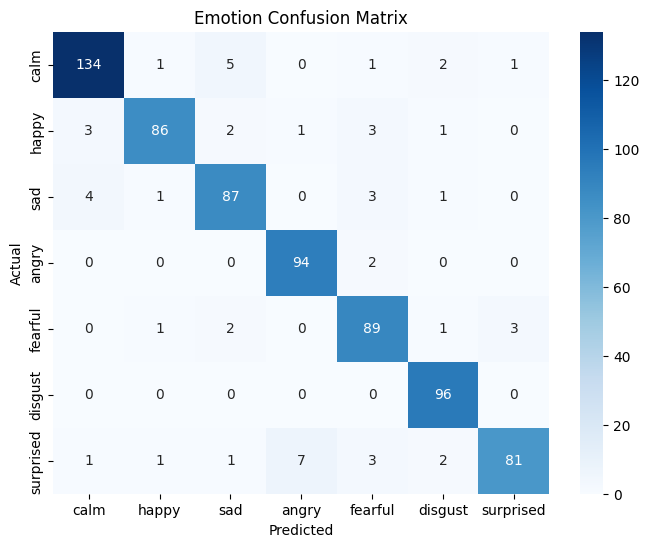


==================== Intensity Report ====================
              precision    recall  f1-score   support

      normal       0.97      0.98      0.97       384
      strong       0.97      0.97      0.97       336

    accuracy                           0.97       720
   macro avg       0.97      0.97      0.97       720
weighted avg       0.97      0.97      0.97       720



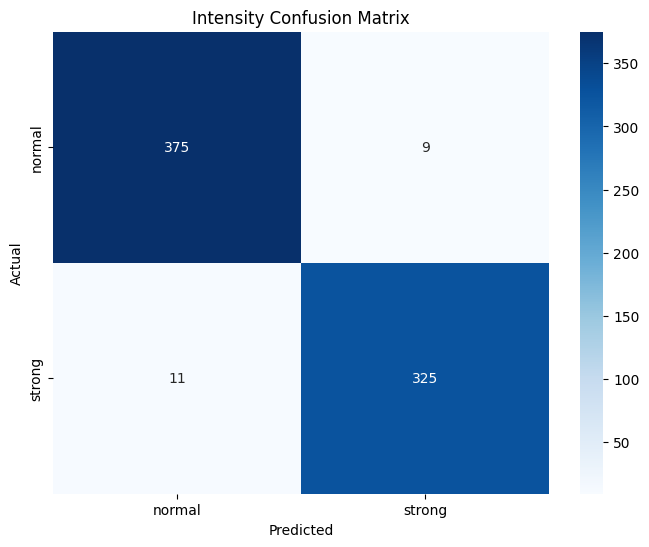


==================== Gender Report ====================
              precision    recall  f1-score   support

        male       1.00      0.99      1.00       360
      female       0.99      1.00      1.00       360

    accuracy                           1.00       720
   macro avg       1.00      1.00      1.00       720
weighted avg       1.00      1.00      1.00       720



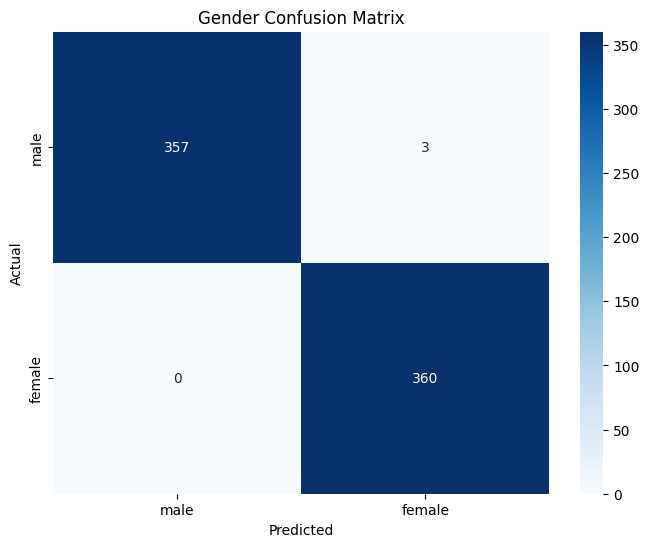

In [40]:
model = tf.keras.models.load_model('best_multi_output_model.keras')
X_test = np.load('X_test.npy')
y_emo_test = np.load('y_emo_test.npy')
y_int_test = np.load('y_int_test.npy')
y_gen_test = np.load('y_gen_test.npy')

predictions = model.predict(X_test)

y_pred_emo = np.argmax(predictions[0], axis=1)
y_pred_int = (predictions[1] > 0.5).astype(int).flatten()
y_pred_gen = (predictions[2] > 0.5).astype(int).flatten()

labels_dict = {
    'Emotion': ['calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised'],
    'Intensity': ['normal', 'strong'],
    'Gender': ['male', 'female']
}

def plot_evaluation(y_true, y_pred, labels, title):
    # Print Classification Report
    print(f"\n{'='*20} {title} Report {'='*20}")
    print(classification_report(y_true, y_pred, target_names=labels))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{title} Confusion Matrix')
    plt.show()

plot_evaluation(y_emo_test, y_pred_emo, labels_dict['Emotion'], "Emotion")
plot_evaluation(y_int_test, y_pred_int, labels_dict['Intensity'], "Intensity")
plot_evaluation(y_gen_test, y_pred_gen, labels_dict['Gender'], "Gender")

In [52]:
SR = 22050
N_MELS = 128
TARGET_WIDTH = 216
HOP_LENGTH = 512

id_to_emotion = {0: 'calm', 1: 'happy', 2: 'sad', 3: 'angry', 4: 'fearful', 5: 'disgust', 6: 'surprised'}
id_to_intensity = {0: 'normal', 1: 'strong'}
id_to_gender = {0: 'male', 1: 'female'}

def predict_single_file(model_path, audio_path):
    # Load Model
    model = tf.keras.models.load_model(model_path)

    # Preprocess Audio
    y, _ = librosa.load(audio_path, sr=SR)
    target_samples = (TARGET_WIDTH - 1) * HOP_LENGTH
    y = librosa.util.fix_length(y, size=target_samples)

    # Extract Features
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    delta = librosa.feature.delta(mel_db)
    delta2 = librosa.feature.delta(mel_db, order=2)
    features = np.stack([mel_db, delta, delta2], axis=-1)

    # Add batch dimension: (1, 128, 216, 3)
    features = np.expand_dims(features, axis=0)

    # Predict
    preds = model.predict(features, verbose=0)

    # Decode Results
    pred_emo = id_to_emotion[np.argmax(preds[0])]
    pred_int = id_to_intensity[1 if preds[1][0][0] > 0.5 else 0]
    pred_gen = id_to_gender[1 if preds[2][0][0] > 0.5 else 0]

    # Confidence (Probabilities)
    emo_conf = np.max(preds[0]) * 100

    return pred_emo, pred_int, pred_gen, emo_conf


test_file = "/content/audio_files_augmented/03-01-05-02-02-01-24__keyboard.wav"
test_file1 = "/content/audio_files_augmented/03-01-07-01-01-01-13__crowd.wav"

def show_predict_result(model_path, audio_path):
    if os.path.exists(audio_path):
        # Using your existing predict_single_file function
        emotion, intensity, gender, confidence = predict_single_file(model_path, audio_path)

        print(f"File: {os.path.basename(audio_path)}")
        print(f"Prediction: {emotion.upper()} ({confidence:.2f}%) | {intensity} | {gender}")
    else:
        print(f"File not found: {audio_path}")

show_predict_result('best_multi_output_model.keras', test_file)
show_predict_result('best_multi_output_model.keras', test_file1)



File: 03-01-05-02-02-01-24__keyboard.wav
Prediction: ANGRY (97.49%) | strong | female
File: 03-01-07-01-01-01-13__crowd.wav
Prediction: DISGUST (74.61%) | normal | male


In [43]:
!unzip -q sein_audio.zip -d my_tests

In [50]:
folder_path = "/content/my_tests"

audio_extensions = ("*.wav", "*.m4a", "*.mp3")

def test_all_files(model_path, folder):
    # Find all audio files
    files_to_test = []
    for ext in audio_extensions:
        files_to_test.extend(glob.glob(os.path.join(folder, ext)))

    if not files_to_test:
        print(f"No audio files found in {folder}")
        return

    print(f"Found {len(files_to_test)} files. Starting predictions...\n")

    for file_path in sorted(files_to_test):
        show_predict_result(model_path, file_path)
        print("-" * 30)

test_all_files('best_multi_output_model.keras', folder_path)

Found 7 files. Starting predictions...

File: angry_sein.wav
Prediction: FEARFUL (55.19%) | strong | female
------------------------------
File: calm_sein.wav
Prediction: SAD (99.00%) | normal | male
------------------------------
File: disgust_sein.wav
Prediction: CALM (95.43%) | strong | male
------------------------------
File: fearful_sein.wav
Prediction: FEARFUL (70.93%) | normal | female
------------------------------
File: happy_sein.wav
Prediction: SAD (99.91%) | strong | female
------------------------------
File: sad_sein.wav
Prediction: SAD (86.19%) | strong | female
------------------------------
File: suprised_sein.wav
Prediction: FEARFUL (94.25%) | normal | female
------------------------------
